## **MINOR** **PROJECT** -**6**

# QuickCart Warehouse Inventory — Stockout Risk Classification
### The Unlox Academy — Supervised ML Classification Project



#SECTION 1 - Project Objective



**Business problem:** QuickCart runs 12 dark stores across 6 Indian metros,
stocking 60 SKUs from 15 suppliers. Every day, for every SKU at every store,
the inventory team needs an early-warning signal: will this item run out of
stock before the next delivery arrives?

**ML objective:** Build a **3-class classifier** that labels every
(store, SKU, day) row as `Safe`, `At-Risk`, or `Imminent`, so the team can
proactively reorder instead of reacting after shelves are already empty.



#SECTION 2 - Import Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    recall_score,
    f1_score
)

##SECTION 3 - Load the Data

In [2]:
stores = pd.read_csv("dim_stores.csv")

skus = pd.read_csv("dim_skus.csv")

suppliers = pd.read_csv(
    "dim_suppliers.csv",
    na_values=['N/A', 'missing', '--', 'NA', 'null']
)
events = pd.read_csv("dim_events.csv")
inventory = pd.read_csv("fact_inventory_daily.csv")

print("\nStores Shape:", stores.shape)
print("SKUs Shape:", skus.shape)
print("Suppliers Shape:", suppliers.shape)
print("Events Shape:", events.shape)
print(" Fact Inventory Shape:", inventory.shape)

print("\nSAMPLE - dim_stores"); print(stores.head())
print("\nSAMPLE - dim_skus"); print(skus.head())
print("\nSAMPLE - dim_suppliers"); print(suppliers.head())
print("\nSAMPLE - dim_events"); print(events.head())
print("\nSAMPLE - fact_inventory_daily"); print(inventory.head())



Stores Shape: (12, 8)
SKUs Shape: (60, 9)
Suppliers Shape: (15, 6)
Events Shape: (30, 5)
 Fact Inventory Shape: (21600, 16)

SAMPLE - dim_stores
  store_id       city city_display city_tier store_size  sqft  opened_year  \
0     ST01     Mumbai       Mumbai     Tier1      Large  2946         2023   
1     ST02     Mumbai       Mumbai     Tier1      Small  1482         2024   
2     ST03  Bengaluru    BENGALURU     Tier1      Large  3650         2022   
3     ST04  Bengaluru    Bengaluru     Tier1      Large  4198         2025   
4     ST05      Delhi        Delhi     Tier1     Medium  2220         2022   

   baseline_daily_orders  
0                    580  
1                    235  
2                    552  
3                    524  
4                    343  

SAMPLE - dim_skus
   sku_id    sku_name             category  unit_price_inr  shelf_life_days  \
0  SKU001  Banana 1kg  Fruits & Vegetables          132.04                2   
1  SKU002  Tomato 1kg  Fruits & Vegetables    

##SECTION 4 - Data Understanding

In [3]:
fact = inventory

# Create dictionary of datasets
datasets = {
    'stores': stores,
    'skus': skus,
    'suppliers': suppliers,
    'events': events,
    'fact': fact
}
# 2. DATA TYPES
print("\n===== DATA TYPES =====")

for name, df in datasets.items():

    print(f"\n--- {name} ---")

    for column in df.columns:

        dtype = df[column].dtype

        if pd.api.types.is_string_dtype(df[column]) or dtype == 'object':
            python_type = "str"

        elif pd.api.types.is_integer_dtype(df[column]):
            python_type = "int"

        elif pd.api.types.is_float_dtype(df[column]):
            python_type = "float"

        elif pd.api.types.is_bool_dtype(df[column]):
            python_type = "bool"

        elif pd.api.types.is_datetime64_any_dtype(df[column]):
            python_type = "datetime"

        else:
            python_type = str(dtype)
        print(f"{column}: {python_type}")

# 3. MISSING VALUES

print("\n===== MISSING VALUES =====")
for name, df in datasets.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]

    print(f"\n--- {name} ---")

    if len(missing) > 0:
        print(missing)
    else:
        print("No missing values")

# 4. DUPLICATE CHECK
print("\n===== DUPLICATE CHECK =====")
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")
# Important grain check for fact table
print(
    "\nDuplicate store + SKU + date:",
    fact.duplicated(
        subset=['date', 'store_id', 'sku_id']
    ).sum()
)
# 5. BASIC KEY CHECK
print("\n===== BASIC KEY CHECK =====")
print(
    "All store_id valid:",
    fact['store_id'].isin(stores['store_id']).all()
)
print(
    "All sku_id valid:",
    fact['sku_id'].isin(skus['sku_id']).all()
)
print(
    "All supplier_id valid:",
    fact['supplier_id'].isin(
        suppliers['supplier_id']
    ).all()
)
# 6. TARGET DISTRIBUTION

print("\n===== TARGET DISTRIBUTION =====")

print(
    fact['stockout_risk']
    .value_counts()
)
print("\nPercentage:")

print(
    (
        fact['stockout_risk']
        .value_counts(normalize=True)
        * 100
    ).round(2)
)
# 7. IMPORTANT MISSING LEAD TIME

print("\n===== LEAD TIME MISSING VALUES =====")
print(
    "Missing:",
    fact['lead_time_days_actual'].isna().sum()
)
print(
    "Percentage:",
    round(
        fact['lead_time_days_actual']
        .isna()
        .mean() * 100,
        2
    ),
    "%"
)
# 8. NUMERICAL SUMMARY

print("\n===== NUMERICAL SUMMARY =====")

print(fact.describe())


===== DATA TYPES =====

--- stores ---
store_id: str
city: str
city_display: str
city_tier: str
store_size: str
sqft: int
opened_year: int
baseline_daily_orders: int

--- skus ---
sku_id: str
sku_name: str
category: str
unit_price_inr: float
shelf_life_days: int
is_perishable: str
festive_relevant: str
popularity_tier: str
supplier_id: str

--- suppliers ---
supplier_id: str
supplier_name: str
categories_supplied: str
reliability_score: float
base_lead_time_days: int
lead_time_variance_days: float

--- events ---
date: str
event_name: str
event_type: str
demand_multiplier_festive: float
demand_multiplier_other: float

--- fact ---
date: str
store_id: str
sku_id: str
supplier_id: str
opening_stock: float
units_demanded: int
units_sold: float
closing_stock: float
reorder_point: float
reorder_placed: str
lead_time_days_expected: int
lead_time_days_actual: float
sales_velocity_7d: float
days_of_cover: float
is_festival_week: str
stockout_risk: str

===== MISSING VALUES =====

--- stores -

##SECTION 5 - Data Cleaning

In [13]:

print("City mismatches before fixing:")
print(
    stores.loc[
        stores['city'] != stores['city_display'],
        ['store_id', 'city', 'city_display']
    ]
)
# Convert city names to title case
stores['city_display'] = stores['city_display'].str.title()

stores['city'] = stores['city'].str.title()

# Check remaining mismatches
print(
    "\nAfter fix - remaining mismatches:",
    (stores['city'] != stores['city_display']).sum()
)
# 2. HANDLE MISSING RELIABILITY SCORE

print(
    "\nreliability_score missing before imputation:",
    suppliers['reliability_score'].isna().sum()
)

# Calculate mean reliability score
mean_reliability = suppliers['reliability_score'].mean()

# Fill missing values with mean
suppliers['reliability_score'] = (
    suppliers['reliability_score']
    .fillna(mean_reliability)
)
print(
    "Imputed with overall mean reliability_score =",
    round(mean_reliability, 4)
)
print(
    "reliability_score missing after imputation:",
    suppliers['reliability_score'].isna().sum()
)

# 3. CONVERT Y/N COLUMNS INTO NUMERICAL FLAGS
# SKU table flags
for col in ['is_perishable', 'festive_relevant']:

    skus[col + '_flag'] = (
        skus[col] == 'Y'
    ).astype(int)

# Fact table flags
for col in ['reorder_placed', 'is_festival_week']:

    fact[col + '_flag'] = (
        fact[col] == 'Y'
    ).astype(int)

print("\nY/N columns converted into numerical flags.")
# 4. CHECK FOR INVALID VALUES
invalid_checks = {

    'negative opening_stock':
        (fact['opening_stock'] < 0).sum(),

    'negative closing_stock':
        (fact['closing_stock'] < 0).sum(),

    'units_sold > units_demanded':
        (fact['units_sold'] > fact['units_demanded']).sum(),

    'invalid reorder_point':
        (fact['reorder_point'] <= 0).sum(),

    'negative sales_velocity_7d':
        (fact['sales_velocity_7d'] < 0).sum(),

    'negative days_of_cover':
        (fact['days_of_cover'] < 0).sum()

}
print("\nInvalid record checks:")

for check, count in invalid_checks.items():

    print(f"{check}: {count}")
# 5. CHECK STRUCTURAL MISSINGNESS
n_reorder_yes = (
    fact['reorder_placed'] == 'Y'
).sum()

n_actual_present = (
    fact['lead_time_days_actual']
    .notna()
    .sum()
)
print(
    "\nreorder_placed == 'Y' count:",
    n_reorder_yes
)
print(
    "lead_time_days_actual non-null count:",
    n_actual_present
)
print(
    "Match confirms missingness is structural, not random:",
    n_reorder_yes == n_actual_present
)
# 6. CHECK DATE RANGES
print(
    "\nFact table date range:",
    fact['date'].min(),
    "to",
    fact['date'].max()
)
print(
    "Events table date range:",
    events['date'].min(),
    "to",
    events['date'].max()
)

City mismatches before fixing:
  store_id       city city_display
2     ST03  Bengaluru    BENGALURU
8     ST09  Hyderabad    hyderabad

After fix - remaining mismatches: 0

reliability_score missing before imputation: 3
Imputed with overall mean reliability_score = 0.7717
reliability_score missing after imputation: 0

Y/N columns converted into numerical flags.

Invalid record checks:
negative opening_stock: 0
negative closing_stock: 0
units_sold > units_demanded: 0
invalid reorder_point: 0
negative sales_velocity_7d: 0
negative days_of_cover: 0

reorder_placed == 'Y' count: 1701
lead_time_days_actual non-null count: 1701
Match confirms missingness is structural, not random: True

Fact table date range: 2026-10-01 to 2026-10-30
Events table date range: 2026-10-01 to 2026-10-30


##SECTION 6 - Merge all tables

In [37]:

n_before = len(fact)
# 1. Merge SKU table
merged = fact.merge(
    skus.drop(columns=['supplier_id']),
    on='sku_id',
    how='left',
    validate='m:1'
)
# 2. Merge Stores table
merged = merged.merge(
    stores,
    on='store_id',
    how='left',
    validate='m:1'
)
# 3. Merge Suppliers table
merged = merged.merge(
    suppliers,
    on='supplier_id',
    how='left',
    validate='m:1'
)
# 4. Merge Events table
merged = merged.merge(
    events,
    on='date',
    how='left',
    validate='m:1'
)
# CHECK MERGED DATASET
print("Final merged shape:", merged.shape)
print("Original rows:", n_before)
print("Final rows:", len(merged))
display(merged.head(5))

Final merged shape: (21600, 43)
Original rows: 21600
Final rows: 21600


,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,...,baseline_daily_orders,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,...,580,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,...,580,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,...,580,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,...,580,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,...,580,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0


##SECTION 7 = Exploratory Data Analysis

stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64


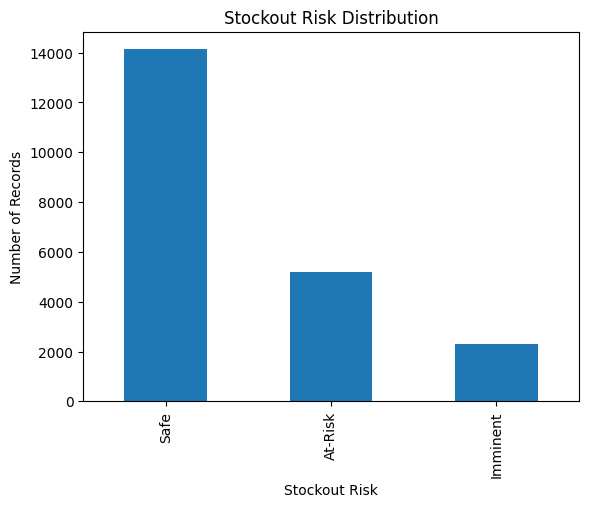

stockout_risk        At-Risk  Imminent  Safe
category                                    
Bakery                   569       564  1027
Beverages                636       419  1825
Dairy                    365       190  1965
Fruits & Vegetables      881       257  2102
Home Care                445       184  1531
Personal Care            483       171  1866
Snacks                   939       330  1971
Staples                  868       168  1844


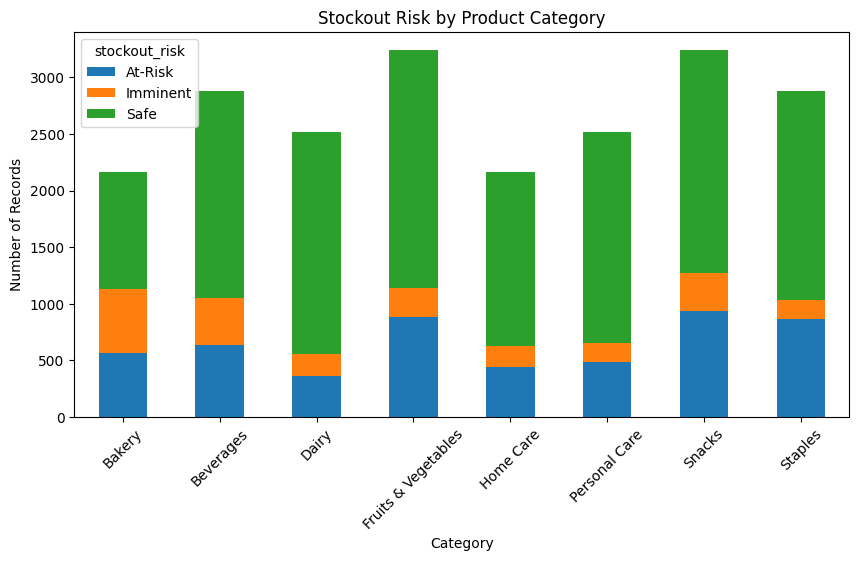

stockout_risk  At-Risk  Imminent  Safe
store_id                              
ST01               446       188  1166
ST02               413       203  1184
ST03               487       155  1158
ST04               495       163  1142
ST05               425       181  1194
ST06               436       197  1167
ST07               424       179  1197
ST08               418       202  1180
ST09               389       193  1218
ST10               413       205  1182
ST11               389       235  1176
ST12               451       182  1167


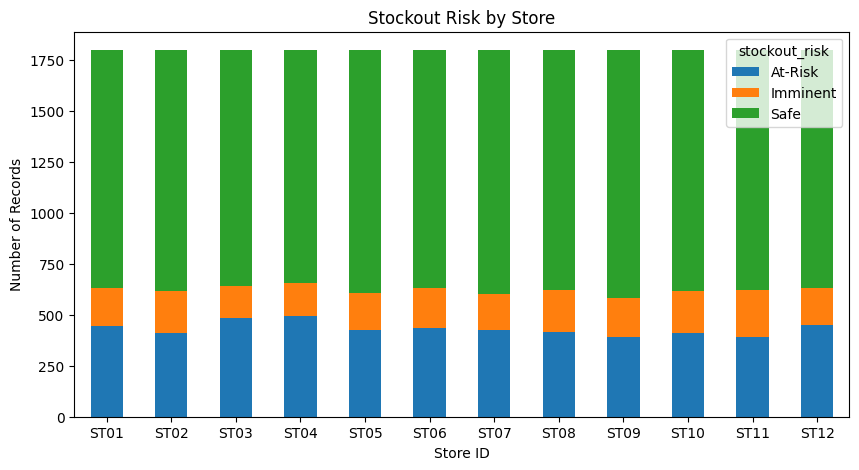

stockout_risk     At-Risk  Imminent   Safe
is_festival_week                          
N                   24.19      9.51  66.30
Y                   21.80     23.31  54.89


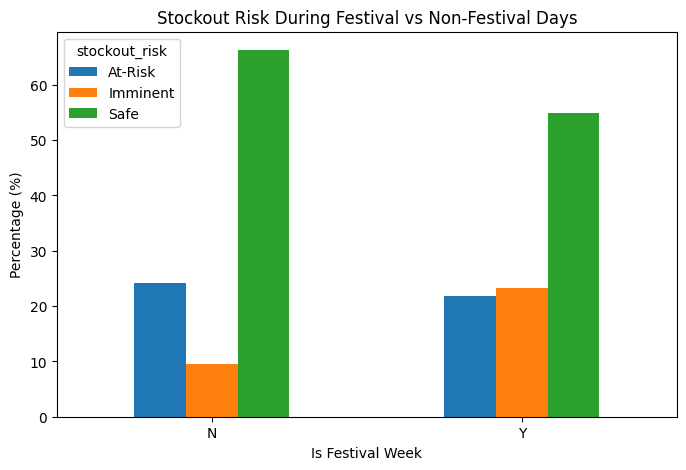

stockout_risk      At-Risk  Imminent   Safe
reliability_group                          
Low                  21.11     15.83  63.06
Medium               21.59      6.30  72.11
High                 34.88      3.82  61.30


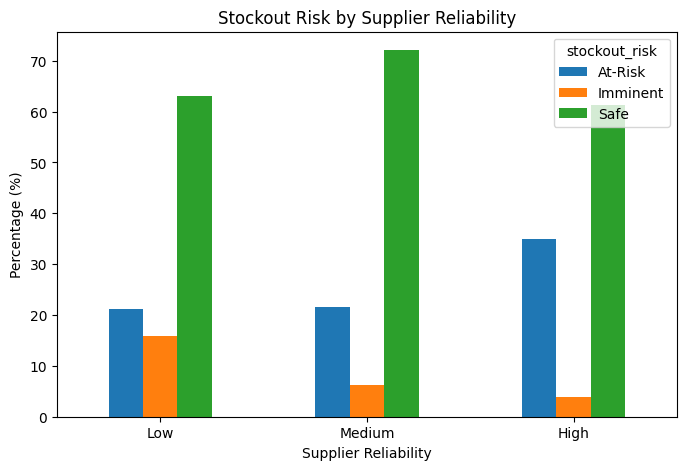

In [38]:

# 1. STOCKOUT RISK DISTRIBUTION

risk_counts = merged['stockout_risk'].value_counts()
print(risk_counts)
risk_counts.plot(
    kind='bar'
)
plt.title('Stockout Risk Distribution')
plt.xlabel('Stockout Risk')
plt.ylabel('Number of Records')
plt.show()

# 2. STOCKOUT RISK BY CATEGORY
category_risk = pd.crosstab(
    merged['category'],
    merged['stockout_risk']
)
print(category_risk)

category_risk.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.title('Stockout Risk by Product Category')
plt.xlabel('Category')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()

# 3. STOCKOUT RISK BY STORE

store_risk = pd.crosstab(
    merged['store_id'],
    merged['stockout_risk']
)
print(store_risk)
store_risk.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)
plt.title('Stockout Risk by Store')
plt.xlabel('Store ID')
plt.ylabel('Number of Records')

plt.xticks(rotation=0)
plt.show()
# 4. FESTIVAL WEEK EFFECT
festival_risk = pd.crosstab(
    merged['is_festival_week'],
    merged['stockout_risk'],
    normalize='index'
) * 100
print(festival_risk.round(2))
festival_risk.plot
    kind='bar',
    figsize=(8, 5)
)
plt.title('Stockout Risk During Festival vs Non-Festival Days')
plt.xlabel('Is Festival Week')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.show()

# 5. SUPPLIER RELIABILITY EFFECT
merged['reliability_group'] = pd.cut(
    merged['reliability_score'],
    bins=[0, 0.75, 0.85, 1],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)
reliability_risk = pd.crosstab(
    merged['reliability_group'],
    merged['stockout_risk'],
    normalize='index'
) * 100
print(reliability_risk.round(2))

reliability_risk.plot(
    kind='bar',
    figsize=(8, 5)
)
plt.title('Stockout Risk by Supplier Reliability')
plt.xlabel('Supplier Reliability')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.show()

##SECTION 7 - Feature Engineering

In [39]:

# Sort data by Store, SKU and Date
df = merged.sort_values(
    ['store_id', 'sku_id', 'date']
).reset_index(drop=True)

# Convert date column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# 1. REORDER GAP
df['reorder_gap'] = (
    df['closing_stock']
    - df['reorder_point']
)
# 2. DAYS OF COVER RATIO
df['days_of_cover_ratio'] = (
    df['days_of_cover']
    / df['lead_time_days_expected']
)

# 3. RECENT REORDER FLAG
df['reorder_placed_numeric'] = df['reorder_placed'].map({'Y': 1, 'N': 0}).fillna(0).astype(int)

df['is_recent_reorder'] = (
    df.groupby(['store_id', 'sku_id'])['reorder_placed_numeric']
    .transform(
        lambda x: x.shift(1)
        .rolling(3, min_periods=1)
        .max()
        .fillna(0)
    )
    .astype(int)
)
# 4. DATE FEATURE
df['day_of_month'] = df['date'].dt.day

# CHECK NEW FEATURES
new_features = [
    'reorder_gap',
    'days_of_cover_ratio',
    'is_recent_reorder',
    'day_of_month'
]
print("New features created:")
print(new_features)
display(df[new_features].head())

New features created:
['reorder_gap', 'days_of_cover_ratio', 'is_recent_reorder', 'day_of_month']


,reorder_gap,days_of_cover_ratio,is_recent_reorder,day_of_month
0,108.5,9.66,0,1
1,98.5,10.79,0,2
2,83.5,8.99,0,3
3,73.5,8.79,0,4
4,64.5,8.55,0,5


##SECTION 8 - Prepare ML data

In [40]:

# SELECT FEATURES (X) AND TARGET (y)
# Convert binary flags to numeric (0/1)
df['is_perishable'] = df['is_perishable'].map({'Y': 1, 'N': 0}).fillna(0).astype(int)
df['festive_relevant'] = df['festive_relevant'].map({'Y': 1, 'N': 0}).fillna(0).astype(int)
df['is_festival_week'] = df['is_festival_week'].map({'Y': 1, 'N': 0}).fillna(0).astype(int)

# Numerical features
numeric_features = [
    'opening_stock',
    'closing_stock',
    'units_demanded',
    'units_sold',
    'reorder_point',
    'sales_velocity_7d',
    'days_of_cover',
    'lead_time_days_expected',
    'reliability_score',
    'reorder_gap',
    'days_of_cover_ratio',
    'day_of_month'
]
# Binary features
binary_features = [
    'is_perishable',
    'festive_relevant',
    'is_festival_week',
    'reorder_placed_numeric',
    'is_recent_reorder'
]
# Categorical features
categorical_features = [
    'category',
    'store_size',
    'popularity_tier',
    'event_type'
]
# Combine all input features
feature_cols = (
    numeric_features
    + binary_features
    + categorical_features
)

# Create X and y
X = df[feature_cols].copy()

y = df['stockout_risk'].copy()
# CHECK FEATURES AND TARGET

print("Total features:", len(feature_cols))

print("\nFeature names:")
print(feature_cols)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)


Total features: 21

Feature names:
['opening_stock', 'closing_stock', 'units_demanded', 'units_sold', 'reorder_point', 'sales_velocity_7d', 'days_of_cover', 'lead_time_days_expected', 'reliability_score', 'reorder_gap', 'days_of_cover_ratio', 'day_of_month', 'is_perishable', 'festive_relevant', 'is_festival_week', 'reorder_placed_numeric', 'is_recent_reorder', 'category', 'store_size', 'popularity_tier', 'event_type']

X shape: (21600, 21)
y shape: (21600,)

Target distribution:
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64

Target percentage:
stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64


##SECTION 9 -  Train/test spilt

In [42]:

# TIME-BASED TRAIN-TEST SPLIT
# Make sure date column is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Split date
split_date = pd.Timestamp('2026-10-24')

# Training data: before 24 October 2026
train_mask = df['date'] < split_date

# Testing data: 24 October 2026 onwards
test_mask = df['date'] >= split_date

# Split features
X_train = X.loc[train_mask].reset_index(drop=True)
X_test = X.loc[test_mask].reset_index(drop=True)

# Split target
y_train = y.loc[train_mask].reset_index(drop=True)
y_test = y.loc[test_mask].reset_index(drop=True)

# CHECK TRAIN AND TEST DATA

print("Train date range:")
print(
    df.loc[train_mask, 'date'].min(),
    "to",
    df.loc[train_mask, 'date'].max()
)
print("\nTest date range:")
print(
    df.loc[test_mask, 'date'].min(),
    "to",
    df.loc[test_mask, 'date'].max()
)
print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(
    y_train.value_counts()
)
print("\nTest target distribution:")
print(
    y_test.value_counts()
)
print("\nTrain target percentage:")
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)
print("\nTest target percentage:")
print(
    (y_test.value_counts(normalize=True) * 100).round(2)
)

Train date range:
2026-10-01 00:00:00 to 2026-10-23 00:00:00

Test date range:
2026-10-24 00:00:00 to 2026-10-30 00:00:00

Train shape: (16560, 21)
Test shape: (5040, 21)

Train target distribution:
stockout_risk
Safe        10992
At-Risk      4060
Imminent     1508
Name: count, dtype: int64

Test target distribution:
stockout_risk
Safe        3139
At-Risk     1126
Imminent     775
Name: count, dtype: int64

Train target percentage:
stockout_risk
Safe        66.38
At-Risk     24.52
Imminent     9.11
Name: proportion, dtype: float64

Test target percentage:
stockout_risk
Safe        62.28
At-Risk     22.34
Imminent    15.38
Name: proportion, dtype: float64


##SECTION 10 - Data Preprocessing

In [54]:

# 1. Remove date column from ML features
X_train = X_train.drop(
    columns=['date'],
    errors='ignore'
)

X_test = X_test.drop(
    columns=['date'],
    errors='ignore'
)
print("Date column removed from ML features.")

# 2. Identify numerical and categorical columns

numeric_features = X_train.select_dtypes(
    include=['int64', 'int32', 'float64', 'float32']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

# 3. Create preprocessing pipelines with imputers
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)
# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)
# 4. Fit preprocessing ONLY on training data
X_train_processed = preprocessor.fit_transform(
    X_train
)
# 5. Transform test data

X_test_processed = preprocessor.transform(
    X_test)
# 6. Check processed data
print("\nPreprocessing completed successfully.")
print(
    "Original X_train shape:",
    X_train.shape
)
print(
    "Processed X_train shape:",
    X_train_processed.shape
)
print(
    "\nOriginal X_test shape:",
    X_test.shape
)
print(
    "Processed X_test shape:",
    X_test_processed.shape
)

Date column removed from ML features.

Numerical Features:
['opening_stock', 'closing_stock', 'units_demanded', 'units_sold', 'reorder_point', 'sales_velocity_7d', 'days_of_cover', 'lead_time_days_expected', 'reliability_score', 'reorder_gap', 'days_of_cover_ratio', 'day_of_month', 'is_perishable', 'festive_relevant', 'is_festival_week', 'reorder_placed_numeric', 'is_recent_reorder']

Categorical Features:
['category', 'store_size', 'popularity_tier', 'event_type']

Preprocessing completed successfully.
Original X_train shape: (16560, 21)
Processed X_train shape: (16560, 34)

Original X_test shape: (5040, 21)
Processed X_test shape: (5040, 34)


##SECTION 11 - Machine learning

In [56]:

# Define models
models = {

    # Baseline: Majority Class Classifier
    'Baseline - Majority Class': DummyClassifier(
        strategy='most_frequent'
    ),
    # Multinomial Logistic Regression
    'Multinomial Logistic Regression': LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ),
    # Random Forest
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}
# Store trained models
trained_models = {}
# Train all models
for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(
        X_train_processed,
        y_train
    )
    trained_models[name] = model

    print(f"{name} trained successfully.")

# Check trained models
print("\nTrained Models:")
print(list(trained_models.keys()))


Training Baseline - Majority Class...
Baseline - Majority Class trained successfully.

Training Multinomial Logistic Regression...


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Multinomial Logistic Regression trained successfully.

Training Random Forest...
Random Forest trained successfully.

Trained Models:
['Baseline - Majority Class', 'Multinomial Logistic Regression', 'Random Forest']


In [48]:

predictions = {}
for name, model in trained_models.items():

    # Generate predictions using test data
    pred = model.predict(X_test_processed)

    # Store predictions
    predictions[name] = pred

    print(f"{name} predictions generated successfully.")
# Display first 10 predictions from each model
for name, pred in predictions.items():
    print(f"\n{name}")
    print("First 10 predictions:")
    print(pred[:10])

Baseline - Majority Class predictions generated successfully.
Multinomial Logistic Regression predictions generated successfully.
Random Forest predictions generated successfully.

Baseline - Majority Class
First 10 predictions:
['Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe']

Multinomial Logistic Regression
First 10 predictions:
['At-Risk' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'At-Risk' 'Imminent'
 'Safe']

Random Forest
First 10 predictions:
['At-Risk' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'At-Risk' 'Imminent'
 'Safe']


##SECTION 12 - Model Evaluation

In [49]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
# Define the required class order
labels_order = [
    'Safe',
    'At-Risk',
    'Imminent'
]
# Store evaluation results
comparison_rows = []
# Evaluate each model
for name, pred in predictions.items():
    # ACCURACY
    accuracy = accuracy_score(
        y_test,
        pred
    )
    # F1 SCORE - MACRO
    f1_macro = f1_score(
        y_test,
        pred,
        average='macro',
        zero_division=0
    )
    # F1 SCORE - WEIGHTED
    f1_weighted = f1_score(
        y_test,
        pred,
        average='weighted',
        zero_division=0
    )
    # RECALL FOR IMMINENT CLASS

    recall_imminent = recall_score(
        y_test,
        pred,
        labels=['Imminent'],
        average='macro',
        zero_division=0
    )
    # PRECISION FOR IMMINENT CLASS
    precision_imminent = precision_score(
        y_test,
        pred,
        labels=['Imminent'],
        average='macro',
        zero_division=0
    )
    # STORE MODEL RESULTS
    comparison_rows.append({
        'Model': name,

        'Accuracy': round(
            accuracy,
            4
        ),
        'F1 (Macro)': round(
            f1_macro,
            4
        ),
        'F1 (Weighted)': round(
            f1_weighted,
            4
        ),
        'Recall - Imminent': round(
            recall_imminent,
            4
        ),
        'Precision - Imminent': round(
            precision_imminent,
            4
        )
    })
    # PRINT RESULT
    print("\n" + "=" * 65)
    print("MODEL:", name)
    print("=" * 65)
    print(
        "Accuracy:",
        round(accuracy, 4)
    )
    print(
        "F1 Score (Macro):",
        round(f1_macro, 4)
    )
    print(
        "F1 Score (Weighted):",
        round(f1_weighted, 4)
    )
    print(
        "Recall - Imminent:",
        round(recall_imminent, 4)
    )
    print(
        "Precision - Imminent:",
        round(precision_imminent, 4)
    )
    # CLASSIFICATION REPORT

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            pred,
            labels=labels_order,
            digits=3,
            zero_division=0
        )
    )


MODEL: Baseline - Majority Class
Accuracy: 0.6228
F1 Score (Macro): 0.2559
F1 Score (Weighted): 0.4781
Recall - Imminent: 0.0
Precision - Imminent: 0.0

Classification Report:
              precision    recall  f1-score   support

        Safe      0.623     1.000     0.768      3139
     At-Risk      0.000     0.000     0.000      1126
    Imminent      0.000     0.000     0.000       775

    accuracy                          0.623      5040
   macro avg      0.208     0.333     0.256      5040
weighted avg      0.388     0.623     0.478      5040


MODEL: Multinomial Logistic Regression
Accuracy: 0.9369
F1 Score (Macro): 0.8954
F1 Score (Weighted): 0.9359
Recall - Imminent: 0.8258
Precision - Imminent: 0.8591

Classification Report:
              precision    recall  f1-score   support

        Safe      0.977     0.999     0.988      3139
     At-Risk      0.872     0.841     0.856      1126
    Imminent      0.859     0.826     0.842       775

    accuracy                       

In [29]:

#  MODEL COMPARISON TABLE
# Convert results into DataFrame
comparison_df = pd.DataFrame(comparison_rows)

# Sort models by Recall - Imminent
# Highest Recall for Imminent comes first
comparison_df = comparison_df.sort_values(
    by='Recall - Imminent',
    ascending=False
).reset_index(drop=True)

# Display comparison table
print("\n" + "=" * 85)
print("MODEL COMPARISON TABLE")
print("=" * 85)

print(
    comparison_df.to_string(index=False)
)


MODEL COMPARISON TABLE
                          Model  Accuracy  F1 (Macro)  F1 (Weighted)  Recall - Imminent  Precision - Imminent
Multinomial Logistic Regression    0.9357      0.8938         0.9347             0.8284                0.8549
                  Random Forest    0.9409      0.8896         0.9395             0.7110                0.9003
      Baseline - Majority Class    0.6228      0.2559         0.4781             0.0000                0.0000


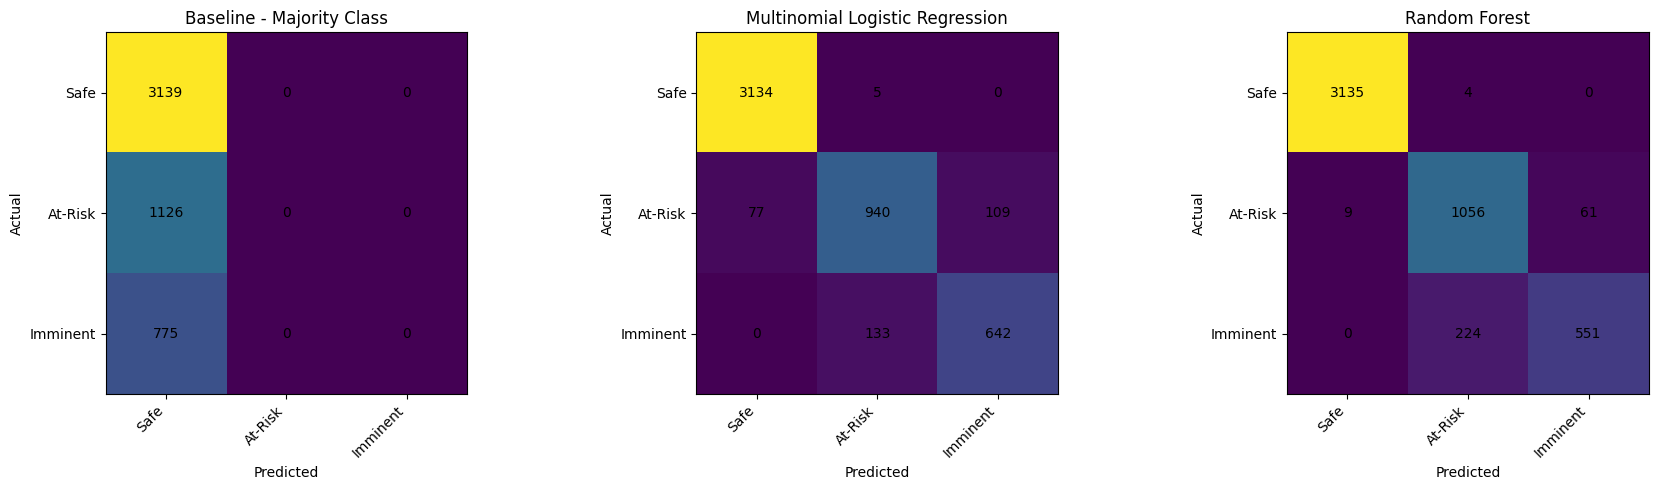

In [30]:

#CONFUSION MATRICES
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Define class order
labels_order = [
    'Safe',
    'At-Risk',
    'Imminent'
]
# Create one graph for each model
fig, axes = plt.subplots(
    1,
    len(predictions),
    figsize=(18, 5)
)
# If only one model exists
if len(predictions) == 1:
    axes = [axes]
# Create confusion matrix for each model
for ax, (name, pred) in zip(axes, predictions.items()):
    # Calculate confusion matrix
    cm = confusion_matrix(
        y_test,
        pred,
        labels=labels_order
    )
    # Display matrix
    ax.imshow(cm)
    # Set labels
    ax.set_xticks(range(len(labels_order)))
    ax.set_xticklabels(
        labels_order,
        rotation=45,
        ha='right'
    )
    ax.set_yticks(range(len(labels_order)))
    ax.set_yticklabels(labels_order)

    # Titles and axis labels
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # Add values inside the matrix
    for i in range(len(labels_order)):
        for j in range(len(labels_order)):

            ax.text(
                j,
                i,
                cm[i, j],
                ha='center',
                va='center'
            )
plt.tight_layout()
plt.show()

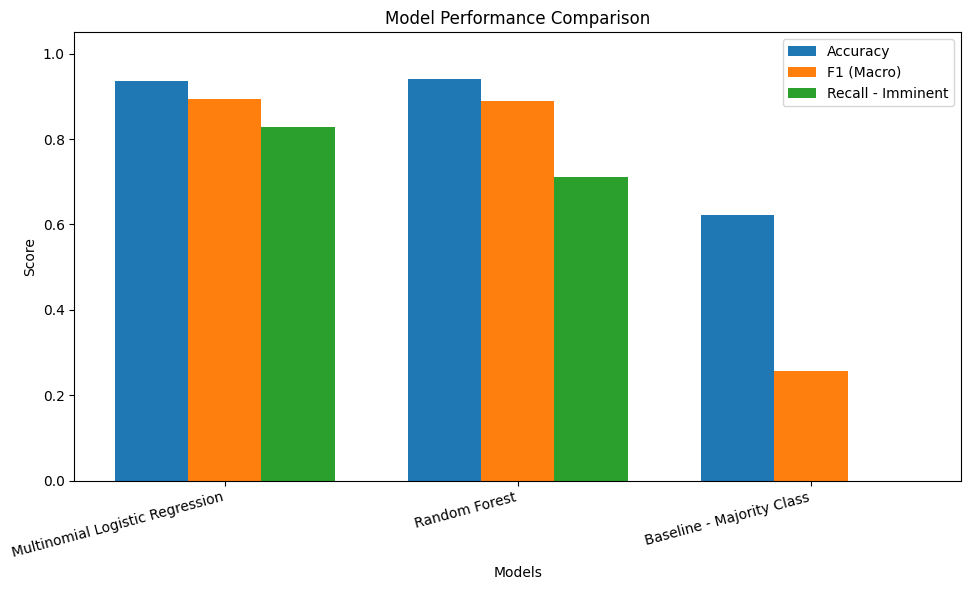

In [31]:

#MODEL COMPARISON GRAPH
# Number of models
x = np.arange(len(comparison_df))

# Width of each bar
width = 0.25

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Accuracy
ax.bar(
    x - width,
    comparison_df['Accuracy'],
    width,
    label='Accuracy'
)
# F1 Macro
ax.bar(
    x,
    comparison_df['F1 (Macro)'],
    width,
    label='F1 (Macro)'
)
# Recall for Imminent
ax.bar(
    x + width,
    comparison_df['Recall - Imminent'],
    width,
    label='Recall - Imminent'
)
# Model names on X-axis
ax.set_xticks(x)

ax.set_xticklabels(
    comparison_df['Model'],
    rotation=15,
    ha='right'
)
# Labels and title
ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
# Score range
ax.set_ylim(0, 1.05)
# Show legend
ax.legend()
# Adjust layout
plt.tight_layout()
# Display graph
plt.show()

##SECTION 14 - Selection of best model

In [32]:

# SELECT THE BEST MODEL
best_model_name = comparison_df.iloc[0]['Model']
# Get the trained best model
best_model = trained_models[best_model_name]

# Get the performance values
best_model_results = comparison_df.iloc[0]

# Display best model
print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print("Best Model:",
      best_model_name)

print("Accuracy:",
      best_model_results['Accuracy'])

print("F1 (Macro):",
      best_model_results['F1 (Macro)'])

print("F1 (Weighted):",
      best_model_results['F1 (Weighted)'])
print("Recall - Imminent:",
      best_model_results['Recall - Imminent'])
print("Precision - Imminent:",
      best_model_results['Precision - Imminent'])

BEST MODEL
Best Model: Multinomial Logistic Regression
Accuracy: 0.9357
F1 (Macro): 0.8938
F1 (Weighted): 0.9347
Recall - Imminent: 0.8284
Precision - Imminent: 0.8549


In [50]:

#FINAL STOCKOUT RISK PREDICTION TABL
best_predictions = predictions[best_model_name]
final_stockout_predictions = X_test.copy()

# Add actual stockout risk
final_stockout_predictions['Actual Stockout Risk'] = y_test.values
# Add predicted stockout risk
final_stockout_predictions['Predicted Stockout Risk'] = best_predictions

# SELECT IMPORTANT COLUMNS
important_columns = [
    'date',
    'store_id',
    'sku_id',
    'Actual Stockout Risk',
    'Predicted Stockout Risk'
]

# Keep only columns that actually exist
available_columns = [
    col for col in important_columns
    if col in final_stockout_predictions.columns
]
# Create final table
final_stockout_predictions = (
    final_stockout_predictions[available_columns]
)

# SET RISK PRIORITY FOR SORTING

risk_order = {
    'Imminent': 1,
    'At-Risk': 2,
    'Safe': 3
}
final_stockout_predictions['risk_priority'] = (
    final_stockout_predictions[
        'Predicted Stockout Risk'
    ].map(risk_order)
)
# SORT FINAL TABLE
sort_columns = []

if 'date' in final_stockout_predictions.columns:
    sort_columns.append('date')

if 'store_id' in final_stockout_predictions.columns:
    sort_columns.append('store_id')

sort_columns.append('risk_priority')

final_stockout_predictions = (
    final_stockout_predictions
    .sort_values(
        by=sort_columns
    )
    .drop(
        columns='risk_priority'
    )
    .reset_index(drop=True)
)
# DISPLAY FINAL RESULTS
print("=" * 70)
print("FINAL STOCKOUT RISK PREDICTIONS")
print("=" * 70)

display(final_stockout_predictions)
# SUMMARY

print("\nTotal number of predictions:")

print(
    len(final_stockout_predictions)
)
print("\nPredicted Stockout Risk Distribution:")

print(
    final_stockout_predictions[
        'Predicted Stockout Risk'
    ].value_counts()
)

FINAL STOCKOUT RISK PREDICTIONS


,Actual Stockout Risk,Predicted Stockout Risk
0,At-Risk,Imminent
1,Imminent,Imminent
2,Imminent,Imminent
3,Imminent,Imminent
4,Imminent,Imminent
...,...,...
5035,Safe,Safe
5036,Safe,Safe
5037,Safe,Safe
5038,Safe,Safe



Total number of predictions:
5040

Predicted Stockout Risk Distribution:
Predicted Stockout Risk
Safe        3209
At-Risk     1086
Imminent     745
Name: count, dtype: int64


##SECTION 15 - Final output

In [57]:

# FINAL OUTPUT: STOCKOUT RISK FOR EACH STORE AND EACH PRODUCT
# Get predictions from the selected best model
best_predictions = predictions[best_model_name]
# 1. GET ORIGINAL TEST DATA
final_results = df.loc[test_mask].copy()

# Reset index to match predictions
final_results = final_results.reset_index(drop=True)

# 2. ADD ACTUAL AND PREDICTED STOCKOUT RISK

final_results['Actual Stockout Risk'] = y_test.reset_index(drop=True)

final_results['Predicted Stockout Risk'] = best_predictions

# 3. SELECT COLUMNS FOR FINAL OUTPUT
desired_columns = [
    'date',
    'store_id',
    'city',
    'sku_id',
    'sku_name',
    'category',
    'supplier_id',
    'closing_stock',
    'sales_velocity_7d',
    'days_of_cover',
    'lead_time_days_expected',
    'Actual Stockout Risk',
    'Predicted Stockout Risk'
]
# Keep only columns that exist in your dataset
available_columns = [
    col for col in desired_columns
    if col in final_results.columns
]
# Create final output table
final_stockout_predictions = final_results[
    available_columns
].copy()

# 4. SET STOCK RISK PRIORITY

risk_order = {
    'Imminent': 1,
    'At-Risk': 2,
    'Safe': 3
}
final_stockout_predictions['risk_priority'] = (
    final_stockout_predictions[
        'Predicted Stockout Risk'
    ].map(risk_order)
)
# 5. SORT BY DATE, STORE, PRODUCT AND RISK
sort_columns = []

# Add columns only if they exist
for col in ['date', 'store_id', 'sku_id']:
    if col in final_stockout_predictions.columns:
        sort_columns.append(col)

sort_columns.append('risk_priority')


final_stockout_predictions = (
    final_stockout_predictions
    .sort_values(by=sort_columns)
    .drop(columns='risk_priority')
    .reset_index(drop=True)
)
# 6. DISPLAY COMPLETE FINAL TABLE
print("=" * 100)
print("FINAL STOCKOUT RISK PREDICTION FOR EACH STORE AND PRODUCT")
print("=" * 100)

print("Best Model Used:", best_model_name)

print("\nTotal Store-Product-Date Records:",
      len(final_stockout_predictions))
# Show all rows and all columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
display(final_stockout_predictions)

FINAL STOCKOUT RISK PREDICTION FOR EACH STORE AND PRODUCT
Best Model Used: Multinomial Logistic Regression

Total Store-Product-Date Records: 5040


,date,store_id,city,sku_id,sku_name,category,supplier_id,closing_stock,sales_velocity_7d,days_of_cover,lead_time_days_expected,Actual Stockout Risk,Predicted Stockout Risk
0,2026-10-24,ST01,Mumbai,SKU001,Banana 1kg,Fruits & Vegetables,SUP11,34.8,12.57,2.77,1,At-Risk,At-Risk
1,2026-10-24,ST01,Mumbai,SKU002,Tomato 1kg,Fruits & Vegetables,SUP08,51.5,22.29,2.31,2,At-Risk,At-Risk
2,2026-10-24,ST01,Mumbai,SKU003,Onion 1kg,Fruits & Vegetables,SUP01,706.4,72.14,9.79,5,Safe,Safe
3,2026-10-24,ST01,Mumbai,SKU004,Potato 1kg,Fruits & Vegetables,SUP01,507.6,45.71,11.10,5,Safe,Safe
4,2026-10-24,ST01,Mumbai,SKU005,Apple 1kg,Fruits & Vegetables,SUP08,339.3,20.19,16.81,2,Safe,Safe
5,2026-10-24,ST01,Mumbai,SKU006,Spinach 250g,Fruits & Vegetables,SUP01,337.5,25.43,13.27,5,Safe,Safe
6,2026-10-24,ST01,Mumbai,SKU007,Cucumber 500g,Fruits & Vegetables,SUP08,36.4,58.57,0.62,2,Imminent,Imminent
7,2026-10-24,ST01,Mumbai,SKU008,Carrot 500g,Fruits & Vegetables,SUP11,237.5,21.00,11.31,1,Safe,Safe
8,2026-10-24,ST01,Mumbai,SKU009,Capsicum 500g,Fruits & Vegetables,SUP08,41.6,36.43,1.14,2,Imminent,Imminent
9,2026-10-24,ST01,Mumbai,SKU010,Toned Milk 1L,Dairy,SUP04,289.5,25.14,11.51,1,Safe,Safe


### Conclusion

The stockout risk prediction model successfully identifies the inventory risk for each store and product using factors such as closing stock, sales velocity, days of cover, and expected supplier lead time. The final output classifies products into **Safe, At-Risk, and Imminent** categories, helping businesses identify products that require immediate attention. Products with low inventory, high sales velocity, and insufficient days of cover can be prioritized for timely replenishment. The comparison between actual and predicted stockout risk also helps evaluate the effectiveness of the machine-learning model. Overall, the project provides a data-driven approach to **proactive inventory management, reducing stockout situations, preventing potential sales loss, and improving replenishment decisions**.
